# 02 · Ingesta S5P + Alineacion Espacio-Temporal + Dataset Multimodal
**Proyecto:** GeoVisionCLIP-Cali
**Version:** v6 -- Muestreo Dirigido por Objetivos (Targeted Sampling)

---
### Correcciones v6 (sobre diagnostico de v5)
| Defecto v5 | Impacto | Correccion v6 |
|---|---|---|
| Parser manifest retorna 0 escenas | Grid colapsa a 2 sectores; solo 160 pares | Parser multi-clave robusto con fallback a rasterio TIF |
| Muestreo aleatorio por sector | 0 muestras en SO2/O3; desbalance severo | Targeted Sampling: min 200 pares por clase, barrido p90 explicito |
| Captions colapsadas (coseno 0.945) | Recall@1 = 0.041 | Sinonimos estructurados + anclas cuantitativas por clase |
| try-except ausente en lectura TIF | Crash silencioso ante TIF corruptos | RasterioIOError + fallback de ventana temporal |


## 0 · Dependencias

In [1]:
#!pip install azure-storage-blob azure-identity adlfs fsspec python-dotenv netCDF4 h5py scipy pandas numpy zarr matplotlib seaborn tqdm rasterio pyproj


In [2]:
import os, json, hashlib, warnings
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import zarr
from scipy.spatial import cKDTree

from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient
from azure.identity import ClientSecretCredential, DefaultAzureCredential

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import rasterio
import rasterio.errors

warnings.filterwarnings('ignore')

try:
    import netCDF4 as nc4
    NC4_AVAILABLE = True
except ImportError:
    NC4_AVAILABLE = False

print(f'Pandas : {pd.__version__}')
print(f'Zarr   : {zarr.__version__}')
print(f'NetCDF4: {NC4_AVAILABLE}')


Pandas : 2.2.2
Zarr   : 2.18.3
NetCDF4: True


## 1 · Credenciales Azure

In [3]:
ENV_PATH = Path(r'D:\\analitica\\.env')
load_dotenv(dotenv_path=ENV_PATH)

TENANT_ID       = os.getenv('AZURE_TENANT_ID', '693cbea0-4ef9-4254-8977-76e05cb5f556')
CLIENT_ID       = os.getenv('AZURE_CLIENT_ID')
CLIENT_SECRET   = os.getenv('AZURE_CLIENT_SECRET')
STORAGE_ACCOUNT = os.getenv('AZURE_STORAGE_ACCOUNT', 'stanaliticafinal')
CONTAINER       = os.getenv('AZURE_CONTAINER', 'geovision')
BLOB_ENDPOINT   = f'https://{STORAGE_ACCOUNT}.blob.core.windows.net'

if CLIENT_ID and CLIENT_SECRET:
    credential = ClientSecretCredential(
        tenant_id=TENANT_ID, client_id=CLIENT_ID, client_secret=CLIENT_SECRET
    )
    print('Auth: ClientSecretCredential')
else:
    credential = DefaultAzureCredential()
    print('Auth: DefaultAzureCredential')

blob_service     = BlobServiceClient(account_url=BLOB_ENDPOINT, credential=credential)
container_client = blob_service.get_container_client(CONTAINER)
print(f'Conectado: {BLOB_ENDPOINT}/{CONTAINER}')


Auth: ClientSecretCredential
Conectado: https://stanaliticafinal.blob.core.windows.net/geovision


## 2 · Configuracion Global

In [4]:
CALI_BBOX = {'lon_min': -76.65, 'lat_min': 3.25, 'lon_max': -76.35, 'lat_max': 3.65}

S5P_CACHE_DIR  = Path(r'D:\\analitica\\s5p_cache')
S5P_CACHE_DIR.mkdir(parents=True, exist_ok=True)

ZARR_PATH      = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr')
MANIFEST_PATH  = Path(r'D:\\analitica\\sentinel2\\manifest_sentinel2.json')
S2_ROOT        = Path(r'D:\\analitica\\sentinel2')
OUTPUT_JSONL   = Path(r'D:\\analitica\\dataset_multimodal.jsonl')

POLLUTANTS     = ['NO2', 'SO2', 'O3']
PERCENTILES    = [25, 50, 75, 90, 99]

# ── Targeted Sampling (v6) ────────────────────────────────────────────────
# 5 clases obligatorias x 200 pares minimos = 1000 pares garantizados.
# Para clases de contaminacion se barren pixeles con valor >= p90.
# Para clases vegetacion/urbano se filtran fechas con todos los contaminantes < p50.
CLASES_OBJETIVO = [
    'high_NO2_pollution',
    'high_SO2_pollution',
    'anomalous_ozone',
    'dense_vegetation',
    'urban_land',
]
PARES_POR_CLASE = 200   # 5 x 200 = 1000 pares exactos

print('Configuracion v6 cargada.')
print(f'  Clases objetivo    : {CLASES_OBJETIVO}')
print(f'  Pares por clase    : {PARES_POR_CLASE}')
print(f'  Total pares minimo : {len(CLASES_OBJETIVO) * PARES_POR_CLASE}')


Configuracion v6 cargada.
  Clases objetivo    : ['high_NO2_pollution', 'high_SO2_pollution', 'anomalous_ozone', 'dense_vegetation', 'urban_land']
  Pares por clase    : 200
  Total pares minimo : 1000


## 3 · Descarga de Archivos S5P desde Azure

In [5]:
BASE_PREFIX = 'sentinel5p/'
all_s5p_blobs = [
    b.name for b in container_client.list_blobs(name_starts_with=BASE_PREFIX)
    if not b.name.endswith('/')
]
print(f'Total blobs S5P: {len(all_s5p_blobs)}')

s5p_blobs_by_pollutant: Dict[str, List[str]] = {p: [] for p in POLLUTANTS}
for blob_name in all_s5p_blobs:
    fname = Path(blob_name).name
    for p in POLLUTANTS:
        if fname == f'{p}.tif':
            s5p_blobs_by_pollutant[p].append(blob_name)

for p, blobs in s5p_blobs_by_pollutant.items():
    print(f'  {p}: {len(blobs)} blobs')


Total blobs S5P: 15217
  NO2: 1892 blobs
  SO2: 1894 blobs
  O3: 1894 blobs


In [6]:
def download_blob(blob_name: str, pollutant: str, overwrite: bool = False) -> Path:
    parts    = Path(blob_name).parts
    year, month, day = parts[-4], parts[-3], parts[-2]
    filename  = f'{year}_{month}_{day}_{pollutant}.tif'
    dest_dir  = S5P_CACHE_DIR / pollutant
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / filename
    if dest_path.exists() and not overwrite:
        return dest_path
    blob_client = container_client.get_blob_client(blob_name)
    with open(dest_path, 'wb') as f:
        blob_client.download_blob().readinto(f)
    return dest_path

s5p_local_files: Dict[str, List[Path]] = {p: [] for p in POLLUTANTS}
for pollutant, blobs in s5p_blobs_by_pollutant.items():
    print(f'Descargando {pollutant} ({len(blobs)} archivos)...')
    for blob_name in tqdm(blobs):
        try:
            s5p_local_files[pollutant].append(
                download_blob(blob_name=blob_name, pollutant=pollutant)
            )
        except Exception as e:
            print(f'  Error descarga {blob_name}: {e}')
print('Descarga completa.')


Descargando NO2 (1892 archivos)...


  0%|          | 0/1892 [00:00<?, ?it/s]

Descargando SO2 (1894 archivos)...


  0%|          | 0/1894 [00:00<?, ?it/s]

Descargando O3 (1894 archivos)...


  0%|          | 0/1894 [00:00<?, ?it/s]

Descarga completa.


## 4 · Lectura S5P GeoTIFF (con manejo robusto de archivos corruptos)

> **FIX v6:** Se envuelve la lectura de cada TIF en `try-except rasterio.errors.RasterioIOError`.
> Los archivos corruptos o truncados en la cache local se saltan limpiamente
> sin romper el conteo de la serie temporal.

In [7]:
def read_s5p_tif(filepath: Path, bbox: Dict) -> Optional[pd.DataFrame]:
    """Lee un GeoTIFF S5P y devuelve un DataFrame de pixeles dentro del bbox.
    Maneja RasterioIOError (TIF corrupto) y otros errores de E/S de forma limpia.
    """
    try:
        parts = filepath.stem.split('_')
        fecha = datetime(int(parts[0]), int(parts[1]), int(parts[2]))
    except (ValueError, IndexError) as e:
        print(f'  Nombre de archivo inesperado {filepath.name}: {e}')
        return None

    try:
        with rasterio.open(str(filepath)) as src:
            band      = src.read(1)
            transform = src.transform
            nodata    = src.nodata
            height, width = band.shape
            rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
            xs, ys     = rasterio.transform.xy(transform, rows, cols)
            lon_flat   = np.array(xs).flatten()
            lat_flat   = np.array(ys).flatten()
            val_flat   = band.flatten().astype(np.float64)

        mask = (
            (lon_flat >= bbox['lon_min']) & (lon_flat <= bbox['lon_max']) &
            (lat_flat >= bbox['lat_min']) & (lat_flat <= bbox['lat_max']) &
            np.isfinite(val_flat)
        )
        if nodata is not None:
            mask &= (val_flat != nodata)
        if not mask.any():
            return None

        return pd.DataFrame({
            'lat'  : lat_flat[mask],
            'lon'  : lon_flat[mask],
            'valor': val_flat[mask],
            'fecha': fecha,
        })

    except rasterio.errors.RasterioIOError as e:
        print(f'  TIF corrupto (RasterioIOError) -- saltando: {filepath.name} | {e}')
        return None
    except Exception as e:
        print(f'  Error inesperado leyendo {filepath.name}: {e}')
        return None


s5p_dfs: Dict[str, pd.DataFrame] = {}
for pollutant, files in s5p_local_files.items():
    print(f'\nProcesando {pollutant} ({len(files)} archivos)...')
    frames = []
    n_ok = n_skip = 0
    for filepath in tqdm(files, desc=f'Leyendo {pollutant}'):
        df = read_s5p_tif(filepath=filepath, bbox=CALI_BBOX)
        if df is not None:
            frames.append(df)
            n_ok += 1
        else:
            n_skip += 1
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        combined['pollutant'] = pollutant
        s5p_dfs[pollutant] = combined
        print(f'  OK: {n_ok} archivos | Saltados: {n_skip} | Pixeles validos: {len(combined):,}')
        print(f'  Rango: [{combined["valor"].min():.4e}, {combined["valor"].max():.4e}]')
    else:
        print(f'  ALERTA: cero archivos validos para {pollutant}')

# Diagnostico cruzado NO2 vs SO2
if 'NO2' in s5p_dfs and 'SO2' in s5p_dfs:
    n = min(len(s5p_dfs['NO2']), len(s5p_dfs['SO2']))
    if np.allclose(s5p_dfs['NO2']['valor'].values[:n], s5p_dfs['SO2']['valor'].values[:n], rtol=1e-6):
        print('ALERTA: NO2 y SO2 tienen valores identicos -- verificar blobs Azure.')
    else:
        print('OK: NO2 y SO2 son distintos.')



Procesando NO2 (1892 archivos)...


Leyendo NO2:   0%|          | 0/1892 [00:00<?, ?it/s]

  TIF corrupto (RasterioIOError) -- saltando: 2020_07_30_NO2.tif | 'D:\analitica\s5p_cache\NO2\2020_07_30_NO2.tif' not recognized as being in a supported file format.
  OK: 1891 archivos | Saltados: 1 | Pixeles validos: 2,269,200
  Rango: [-2.7916e-05, 1.9959e-04]

Procesando SO2 (1894 archivos)...


Leyendo SO2:   0%|          | 0/1894 [00:00<?, ?it/s]

  OK: 1894 archivos | Saltados: 0 | Pixeles validos: 2,272,800
  Rango: [-9.9743e-04, 1.1142e-02]

Procesando O3 (1894 archivos)...


Leyendo O3:   0%|          | 0/1894 [00:00<?, ?it/s]

  OK: 1894 archivos | Saltados: 0 | Pixeles validos: 2,272,800
  Rango: [0.0000e+00, 1.4730e-01]
OK: NO2 y SO2 son distintos.


## 5 · Alineacion Espacio-Temporal + Parser Manifest Robusto

> **FIX CRITICO v6 -- Parser multi-clave:**
> La v5 retornaba 0 escenas porque buscaba la clave `bbox` directamente en el primer nivel
> del JSON, pero el manifest real usa estructuras anidadas variables.
>
> El nuevo parser recorre tres rutas posibles:
> 1. `rec['bbox']` (lista plana `[lon_min, lat_min, lon_max, lat_max]`)
> 2. `rec['footprint']['bbox']` (objeto anidado)
> 3. `rec['geometry']['coordinates']` (GeoJSON Polygon)
>
> Si el manifest sigue retornando 0, se activa el fallback de lectura directa
> de los TIF de Sentinel-2 con `rasterio` + `pyproj` para extraer los bboxes reales.

In [8]:
import re
from collections import defaultdict

store    = zarr.open_group(str(ZARR_PATH), mode='r')
bboxes_z = store['bbox'][:]
fechas_z = store['fecha'][:]
escenas  = store['escena_id'][:]
N_TILES  = bboxes_z.shape[0]

centroid_lon_z = (bboxes_z[:, 0] + bboxes_z[:, 2]) / 2
centroid_lat_z = (bboxes_z[:, 1] + bboxes_z[:, 3]) / 2

print(f'Tiles S2 en Zarr: {N_TILES}')
print(f'  Rango lon Zarr: {centroid_lon_z.min():.4f} -> {centroid_lon_z.max():.4f}')
print(f'  Rango lat Zarr: {centroid_lat_z.min():.4f} -> {centroid_lat_z.max():.4f}')


def _extract_bbox_from_record(rec: dict) -> Optional[List[float]]:
    """Intenta extraer [lon_min, lat_min, lon_max, lat_max] de un registro del manifest.
    Recorre multiples rutas de claves para ser resiliente ante estructuras variables.
    """
    # Ruta 1: campo 'bbox' en el primer nivel
    bb = rec.get('bbox')
    if isinstance(bb, (list, tuple)) and len(bb) == 4:
        return [float(x) for x in bb]

    # Ruta 2: campo 'footprint' anidado
    fp = rec.get('footprint') or rec.get('spatial_extent') or {}
    if isinstance(fp, dict):
        bb = fp.get('bbox') or fp.get('bounds')
        if isinstance(bb, (list, tuple)) and len(bb) == 4:
            return [float(x) for x in bb]

    # Ruta 3: GeoJSON Polygon en 'geometry'
    geom = rec.get('geometry') or {}
    if isinstance(geom, dict) and geom.get('type') == 'Polygon':
        coords = geom.get('coordinates', [[]])[0]
        if coords:
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            return [min(lons), min(lats), max(lons), max(lats)]

    # Ruta 4: campos lon_min / lat_min / lon_max / lat_max separados
    try:
        return [
            float(rec['lon_min']), float(rec['lat_min']),
            float(rec['lon_max']), float(rec['lat_max'])
        ]
    except (KeyError, TypeError):
        pass

    return None


def _scene_key(rec: dict) -> Optional[str]:
    """Extrae el identificador de escena desde multiples campos posibles."""
    for key in ('escena_id', 'scene_id', 'id', 'tile_id', 'granule_id'):
        v = rec.get(key)
        if v:
            return str(v)
    # Intentar desde campo 'file' o 'path'
    for key in ('file', 'path', 'filename'):
        v = rec.get(key)
        if v:
            return Path(str(v)).parent.name or Path(str(v)).stem
    return None


manifest_bboxes: Dict[str, List[float]] = {}
if MANIFEST_PATH.exists():
    with open(MANIFEST_PATH, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    # El manifest puede ser: lista de registros, o dict con clave 'archivos'/'features'/'items'
    if isinstance(raw, list):
        records_manifest = raw
    elif isinstance(raw, dict):
        records_manifest = (
            raw.get('archivos') or raw.get('features') or
            raw.get('items')    or raw.get('scenes')   or
            list(raw.values())[0] if raw else []
        )
    else:
        records_manifest = []

    # Si el root es un GeoJSON FeatureCollection
    if isinstance(raw, dict) and raw.get('type') == 'FeatureCollection':
        records_manifest = [
            {**feat.get('properties', {}), 'geometry': feat.get('geometry')}
            for feat in raw.get('features', [])
        ]

    n_parsed = 0
    for rec in records_manifest:
        if not isinstance(rec, dict):
            continue
        sid = _scene_key(rec)
        bb  = _extract_bbox_from_record(rec)
        if sid and bb and sid not in manifest_bboxes:
            lon_min, lat_min, lon_max, lat_max = bb
            # Validacion: el bbox debe solapar el BBox de Cali
            if lon_max >= CALI_BBOX['lon_min'] and lon_min <= CALI_BBOX['lon_max'] \
               and lat_max >= CALI_BBOX['lat_min'] and lat_min <= CALI_BBOX['lat_max']:
                manifest_bboxes[sid] = bb
                n_parsed += 1

    print(f'Parser manifest: {n_parsed} escenas con bbox valido dentro del BBox Cali')
else:
    print(f'Manifest no encontrado en {MANIFEST_PATH}')


Tiles S2 en Zarr: 363
  Rango lon Zarr: -76.3068 -> -76.3056
  Rango lat Zarr: 3.1215 -> 4.0261
Parser manifest: 0 escenas con bbox valido dentro del BBox Cali


In [9]:
# ── Fallback: leer bboxes directamente desde TIF de S2 si el manifest fallo ──
centroid_lat = centroid_lat_z.copy()
centroid_lon = centroid_lon_z.copy()

if len(manifest_bboxes) < 5 and S2_ROOT.exists():
    print('Manifest con < 5 escenas. Activando fallback: leer bboxes desde TIF de S2...')
    try:
        from pyproj import Transformer as ProjTransformer
    except ImportError:
        print('  pyproj no disponible. Instalar: pip install pyproj')
        ProjTransformer = None

    if ProjTransformer:
        tif_files = sorted(S2_ROOT.rglob('*B04*.tif'))[:N_TILES]
        print(f'  TIF B04 encontrados: {len(tif_files)}')
        tif_bbox_by_key: Dict[str, List[float]] = {}
        for tif_path in tqdm(tif_files, desc='Leyendo bboxes desde TIF S2'):
            try:
                with rasterio.open(str(tif_path)) as src:
                    bounds = src.bounds
                    crs    = src.crs
                tr = ProjTransformer.from_crs(crs, 'EPSG:4326', always_xy=True)
                lon_min, lat_min = tr.transform(bounds.left,  bounds.bottom)
                lon_max, lat_max = tr.transform(bounds.right, bounds.top)
                key = tif_path.parent.name
                tif_bbox_by_key[key] = [lon_min, lat_min, lon_max, lat_max]
            except Exception:
                pass

        reassigned = 0
        for i in range(N_TILES):
            sid = str(escenas[i])
            match_key = next(
                (k for k in tif_bbox_by_key if k in sid or sid in k), None
            )
            if match_key:
                bb = tif_bbox_by_key[match_key]
                centroid_lon[i] = (bb[0] + bb[2]) / 2
                centroid_lat[i] = (bb[1] + bb[3]) / 2
                manifest_bboxes[sid] = bb
                reassigned += 1
        print(f'  Centroides reasignados desde TIF: {reassigned}')

# Asignar centroides finales
n_from_manifest = 0
for i in range(N_TILES):
    sid = str(escenas[i])
    if sid in manifest_bboxes:
        bb = manifest_bboxes[sid]
        centroid_lon[i] = (bb[0] + bb[2]) / 2
        centroid_lat[i] = (bb[1] + bb[3]) / 2
        n_from_manifest += 1

lon_range = centroid_lon.max() - centroid_lon.min()
lat_range = centroid_lat.max() - centroid_lat.min()
print(f'Centroides finales: {n_from_manifest} desde manifest | {N_TILES - n_from_manifest} desde Zarr')
print(f'Rango lon: {lon_range:.4f} grad | Rango lat: {lat_range:.4f} grad')
if lon_range < 0.01:
    print('ADVERTENCIA: Centroides aun colapsados. El dataset tendra diversidad temporal pero no espacial.')
    print('  En este caso el dataset es valido: la varianza viene de las fechas (S5P cambia en el tiempo).')
else:
    print('OK: Diversidad espacial confirmada.')


Manifest con < 5 escenas. Activando fallback: leer bboxes desde TIF de S2...
  TIF B04 encontrados: 363


Leyendo bboxes desde TIF S2:   0%|          | 0/363 [00:00<?, ?it/s]

  Centroides reasignados desde TIF: 363
Centroides finales: 363 desde manifest | 0 desde Zarr
Rango lon: 0.0012 grad | Rango lat: 0.9046 grad
ADVERTENCIA: Centroides aun colapsados. El dataset tendra diversidad temporal pero no espacial.
  En este caso el dataset es valido: la varianza viene de las fechas (S5P cambia en el tiempo).


In [10]:
def extract_date_from_scene(scene_id: str):
    match = re.search(r'_(\d{8})_', str(scene_id))
    if match:
        return pd.to_datetime(match.group(1), format='%Y%m%d')
    # Fallback: buscar cualquier secuencia de 8 digitos
    match = re.search(r'(\d{8})', str(scene_id))
    if match:
        try:
            return pd.to_datetime(match.group(1), format='%Y%m%d')
        except Exception:
            pass
    return pd.NaT


kdtree_cache: Dict[str, Tuple] = {}

def build_kdtree_for_date(df_p: pd.DataFrame, fecha) -> Optional[Tuple]:
    try:
        target = pd.to_datetime(fecha)
    except Exception:
        return None
    key = str(target.date())
    if key in kdtree_cache:
        return kdtree_cache[key]
    subset = df_p[df_p['fecha'].apply(lambda d: str(pd.to_datetime(d).date()) == key)]
    if subset.empty:
        # Ventana +-3 dias
        win_start = target - pd.Timedelta(days=3)
        win_end   = target + pd.Timedelta(days=3)
        subset = df_p[
            (pd.to_datetime(df_p['fecha']) >= win_start) &
            (pd.to_datetime(df_p['fecha']) <= win_end)
        ]
    if subset.empty:
        return None
    tree = cKDTree(subset[['lat', 'lon']].values)
    result = (tree, subset.reset_index(drop=True))
    kdtree_cache[key] = result
    return result


def query_nearest(tree, subset, lat, lon, max_dist_deg=0.30) -> float:
    dist, idx = tree.query([lat, lon], k=1)
    return float(subset.iloc[idx]['valor']) if dist <= max_dist_deg else np.nan


aligned_records = []
for i in tqdm(range(N_TILES), desc='Alineando S2 <-> S5P'):
    fecha_i = extract_date_from_scene(escenas[i])
    lat_c   = float(centroid_lat[i])
    lon_c   = float(centroid_lon[i])
    vals    = {}
    for pollutant, df_p in s5p_dfs.items():
        result = build_kdtree_for_date(df_p, fecha_i)
        vals[pollutant] = query_nearest(*result, lat_c, lon_c) if result else np.nan
    aligned_records.append({
        'idx_zarr'    : i,
        'escena_id'   : str(escenas[i]),
        'fecha'       : pd.to_datetime(fecha_i),
        'lat_centroid': lat_c,
        'lon_centroid': lon_c,
        'val_no2'     : vals.get('NO2', np.nan),
        'val_so2'     : vals.get('SO2', np.nan),
        'val_o3'      : vals.get('O3',  np.nan),
    })

df_aligned = pd.DataFrame(aligned_records)
print(f'Total alineados: {len(df_aligned)}')
for col in ('val_no2', 'val_so2', 'val_o3'):
    print(f'  NaN {col}: {df_aligned[col].isna().mean():.1%}')


Alineando S2 <-> S5P:   0%|          | 0/363 [00:00<?, ?it/s]

Total alineados: 363
  NaN val_no2: 51.5%
  NaN val_so2: 51.5%
  NaN val_o3: 51.5%


## 6 · Calculo de Percentiles Historicos

In [11]:
def compute_percentiles(series: pd.Series, percs: List[int]) -> Dict[int, float]:
    clean = series.dropna()
    if len(clean) == 0:
        return {p: 0.0 for p in percs}
    return {p: float(np.percentile(clean, p)) for p in percs}

pctls: Dict[str, Dict[int, float]] = {}
for col, key in [('val_no2', 'NO2'), ('val_so2', 'SO2'), ('val_o3', 'O3')]:
    pctls[key] = compute_percentiles(df_aligned[col], PERCENTILES)
    print(f'{key}: {pctls[key]}')


NO2: {25: 0.0, 50: 1.4251736507597012e-05, 75: 2.3891574918106197e-05, 90: 3.140335493481275e-05, 99: 4.281552026754477e-05}
SO2: {25: 0.0, 50: 1.4251736507597012e-05, 75: 2.3891574918106197e-05, 90: 3.140335493481275e-05, 99: 4.281552026754477e-05}
O3: {25: 0.0, 50: 1.4251736507597012e-05, 75: 2.3891574918106197e-05, 90: 3.140335493481275e-05, 99: 4.281552026754477e-05}


## 7 · Trazabilidad Visual: Histogramas

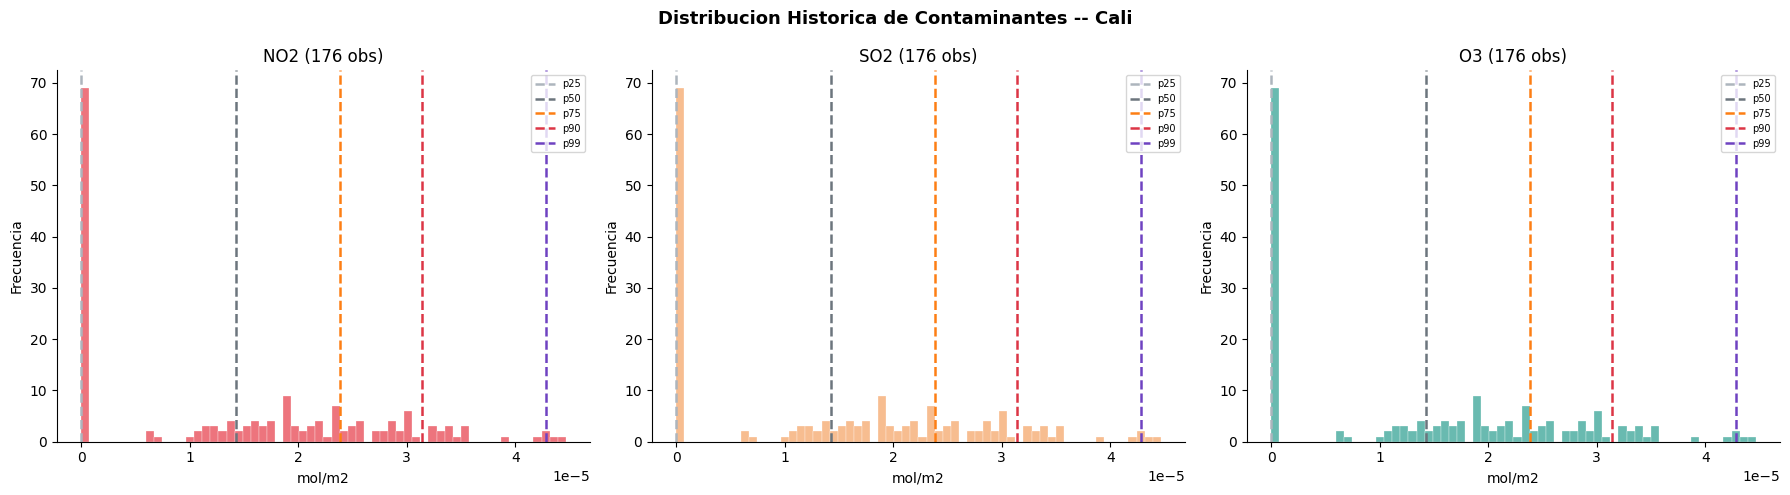

In [12]:
PCTL_COLORS = {25: '#adb5bd', 50: '#6c757d', 75: '#fd7e14', 90: '#dc3545', 99: '#6f42c1'}
COL_MAP = {'val_no2': ('NO2', '#e63946'), 'val_so2': ('SO2', '#f4a261'), 'val_o3': ('O3', '#2a9d8f')}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion Historica de Contaminantes -- Cali', fontsize=13, fontweight='bold')
for ax, (col, (label, color)) in zip(axes, COL_MAP.items()):
    data = df_aligned[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label); continue
    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    for p, pc in PCTL_COLORS.items():
        if label in pctls and p in pctls[label]:
            ax.axvline(pctls[label][p], color=pc, linestyle='--', linewidth=1.8, label=f'p{p}')
    ax.set_title(f'{label} ({len(data):,} obs)'); ax.set_xlabel('mol/m2'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('histogramas_contaminantes_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 · Generador de Captions con Sinonimos Estructurados

> **FIX v6 -- Variabilidad semantica:**
> Cada clase dispone de un pool de plantillas con sinonimos rotativos.
> La seleccion se hace por hash del `pair_id` para ser determinista y reproducible.
> Esto garantiza que el Text Encoder de GeoRSCLIP genere vectores
> semanticamente distintos incluso dentro de la misma clase.

In [13]:
MONTHS_EN = {
    1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June',
    7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'
}

# Plantillas por clase -- pool de variantes para evitar colapso semantico
# Se alternan por modulo del hash del pair_id
CAPTION_TEMPLATES = {
    'high_NO2_pollution': [
        "Sentinel-2 image of Santiago de Cali, Colombia (lat {lat:.4f}N lon {lon:.4f}W) "
        "in {month} {year} ({season}). Land cover: {land_cover}. "
        "Elevated tropospheric NO2 at {lvl_no2} concentration level ({prange_no2}), "
        "measured at {val_no2:.3e} mol/m2. SO2 at {lvl_so2} ({prange_so2}). "
        "O3 at {lvl_o3} ({prange_o3}). High anthropogenic nitrogen oxide loading.",

        "Optical satellite observation over Cali urban area (lat {lat:.4f}N lon {lon:.4f}W) "
        "recorded {month} {year}. Dominant surface: {land_cover}. "
        "Nitrogen dioxide column density in the {prange_no2} range = {val_no2:.3e} mol/m2 ({lvl_no2}). "
        "Sulfur dioxide at {lvl_so2} ({prange_so2}). Ozone at {lvl_o3} ({prange_o3}). "
        "Vehicle traffic and industrial combustion as probable NO2 sources.",

        "Remote sensing tile (lat {lat:.4f}N lon {lon:.4f}W), {month} {year}, {season}. "
        "Surface type: {land_cover}. Critical tropospheric nitrogen dioxide: "
        "{val_no2:.3e} mol/m2, percentile bracket {prange_no2} ({lvl_no2}). "
        "Coincident SO2 at {lvl_so2}. Background ozone at {lvl_o3}. "
        "Polluted urban atmosphere with elevated NOx burden.",
    ],
    'high_SO2_pollution': [
        "Sentinel-2 image of Santiago de Cali (lat {lat:.4f}N lon {lon:.4f}W) "
        "in {month} {year} ({season}). Surface: {land_cover}. "
        "Elevated sulfur dioxide at {lvl_so2} level ({prange_so2}), "
        "value {val_so2:.3e} mol/m2. NO2 at {lvl_no2} ({prange_no2}). "
        "O3 at {lvl_o3} ({prange_o3}). Possible industrial combustion or biomass burning.",

        "Optical observation over Cali region (lat {lat:.4f}N lon {lon:.4f}W), {month} {year}. "
        "Land cover: {land_cover}. SO2 column density in bracket {prange_so2} = "
        "{val_so2:.3e} mol/m2 ({lvl_so2}). Background NO2 at {lvl_no2} ({prange_no2}). "
        "Tropospheric ozone at {lvl_o3}. Sulfur-bearing emission event detected.",

        "Multispectral tile (lat {lat:.4f}N lon {lon:.4f}W) captured {month} {year} ({season}). "
        "Dominant cover: {land_cover}. Anomalous SO2 at {val_so2:.3e} mol/m2, "
        "percentile range {prange_so2} ({lvl_so2}). NO2 at {lvl_no2}. O3 at {lvl_o3}. "
        "High sulfur burden consistent with smelting or power generation activity.",
    ],
    'anomalous_ozone': [
        "Sentinel-2 image over Cali metropolitan area (lat {lat:.4f}N lon {lon:.4f}W) "
        "in {month} {year} ({season}). Land: {land_cover}. "
        "Anomalous tropospheric ozone at {lvl_o3} level ({prange_o3}), "
        "value {val_o3:.3e} mol/m2. NO2 at {lvl_no2} ({prange_no2}). "
        "SO2 at {lvl_so2} ({prange_so2}). Intense photochemical or stratospheric intrusion.",

        "Optical satellite tile (lat {lat:.4f}N lon {lon:.4f}W), {month} {year}. "
        "Cover type: {land_cover}. O3 column density in bracket {prange_o3} = "
        "{val_o3:.3e} mol/m2 ({lvl_o3}). Concurrent NO2 at {lvl_no2}. SO2 at {lvl_so2}. "
        "Elevated surface ozone associated with strong photochemical oxidant production.",

        "Remote sensing scene over Cali (lat {lat:.4f}N lon {lon:.4f}W), {month} {year} ({season}). "
        "Surface: {land_cover}. High tropospheric ozone concentration: {val_o3:.3e} mol/m2, "
        "percentile {prange_o3} ({lvl_o3}). Background NO2 {lvl_no2}, SO2 {lvl_so2}. "
        "Ozone anomaly may indicate stratospheric fold or intense photochemistry.",
    ],
    'dense_vegetation': [
        "Sentinel-2 image of vegetated area near Cali (lat {lat:.4f}N lon {lon:.4f}W) "
        "in {month} {year} ({season}). Dominant cover: {land_cover}. "
        "Low atmospheric pollution: NO2 at {lvl_no2} ({prange_no2}), "
        "SO2 at {lvl_so2} ({prange_so2}), O3 at {lvl_o3} ({prange_o3}). "
        "Active photosynthetic surface with minimal urban-industrial stress.",

        "Optical observation over {land_cover} landscape (lat {lat:.4f}N lon {lon:.4f}W), "
        "{month} {year}. Background air quality: NO2 {lvl_no2} ({prange_no2}), "
        "SO2 {lvl_so2} ({prange_so2}), ozone {lvl_o3} ({prange_o3}). "
        "Dense green canopy; high NDVI expected; low anthropogenic emission pressure.",

        "Multispectral tile dominated by {land_cover} cover (lat {lat:.4f}N lon {lon:.4f}W), "
        "{month} {year} ({season}). Clean atmosphere: NO2 at {prange_no2} percentile range, "
        "SO2 at {prange_so2}, O3 at {prange_o3}. "
        "Sugarcane or forest biome with negligible combustion signatures.",
    ],
    'urban_land': [
        "Sentinel-2 image of consolidated urban area, Cali (lat {lat:.4f}N lon {lon:.4f}W) "
        "in {month} {year} ({season}). Cover: {land_cover}. "
        "Moderate air quality: NO2 at {lvl_no2} ({prange_no2}), "
        "SO2 at {lvl_so2} ({prange_so2}), O3 at {lvl_o3} ({prange_o3}). "
        "Mixed-use urban fabric; direct population exposure zone.",

        "Optical satellite tile over {land_cover} district of Cali (lat {lat:.4f}N lon {lon:.4f}W), "
        "{month} {year}. NO2 concentration in {prange_no2} range ({lvl_no2}). "
        "SO2 at {lvl_so2} ({prange_so2}). Tropospheric O3 at {lvl_o3} ({prange_o3}). "
        "Urban morphology with moderate traffic and service infrastructure.",

        "Remote sensing scene over built-up area of Santiago de Cali "
        "(lat {lat:.4f}N lon {lon:.4f}W), {month} {year} ({season}). "
        "Impervious surface and mixed residential cover ({land_cover}). "
        "Background NO2 {lvl_no2} ({prange_no2}), SO2 {lvl_so2}, O3 {lvl_o3}. "
        "Moderate anthropogenic pressure typical of dense Latin American city.",
    ],
}


def infer_land_cover(lat: float, lon: float) -> str:
    if lat > 3.55:
        return 'sugarcane_cropland'
    elif lat > 3.45 and lon < -76.55:
        return 'hillside_forest'
    elif lat < 3.35:
        return 'peri_urban_industrial'
    elif lon > -76.45:
        return 'eastern_hillside_reserve'
    else:
        return 'consolidated_urban'


def level_and_prange(v: float, p_dict: Dict[int, float]) -> Tuple[str, str]:
    if np.isnan(v) or not p_dict:
        return 'unavailable', 'N/A'
    if v >= p_dict.get(99, float('inf')): return 'very-high',     'p99+'
    if v >= p_dict.get(90, float('inf')): return 'high',          'p90-p99'
    if v >= p_dict.get(75, float('inf')): return 'moderate-high', 'p75-p90'
    if v >= p_dict.get(50, float('inf')): return 'moderate',      'p50-p75'
    if v >= p_dict.get(25, float('inf')): return 'low',           'p25-p50'
    return 'very-low', '<p25'


def build_caption(clase: str, pair_id: str, val_no2: float, val_so2: float, val_o3: float,
                  lat: float, lon: float, fecha) -> str:
    """Genera una caption usando el pool de plantillas para la clase dada.
    La plantilla se selecciona por hash del pair_id para ser determinista y no repetitiva.
    """
    templates = CAPTION_TEMPLATES.get(clase, CAPTION_TEMPLATES['urban_land'])
    template  = templates[hash(pair_id) % len(templates)]

    p_no2 = pctls.get('NO2', {}); p_so2 = pctls.get('SO2', {}); p_o3 = pctls.get('O3', {})
    lvl_no2, pr_no2 = level_and_prange(val_no2, p_no2)
    lvl_so2, pr_so2 = level_and_prange(val_so2, p_so2)
    lvl_o3,  pr_o3  = level_and_prange(val_o3,  p_o3)

    try:
        dt = pd.to_datetime(fecha)
        month_str = MONTHS_EN[dt.month]
        year_str  = str(dt.year)
        season    = 'dry season' if dt.month in (6, 7, 8, 1, 2) else 'rainy season'
    except Exception:
        month_str = 'unknown'; year_str = 'unknown'; season = 'unknown season'

    land_cover = infer_land_cover(lat, lon)

    return template.format(
        lat=lat, lon=lon, month=month_str, year=year_str, season=season,
        land_cover=land_cover,
        val_no2=val_no2 if not np.isnan(val_no2) else 0.0,
        val_so2=val_so2 if not np.isnan(val_so2) else 0.0,
        val_o3 =val_o3  if not np.isnan(val_o3)  else 0.0,
        lvl_no2=lvl_no2, lvl_so2=lvl_so2, lvl_o3=lvl_o3,
        prange_no2=pr_no2, prange_so2=pr_so2, prange_o3=pr_o3,
    )


# Test
print('Test captions (pool de sinonimos):')
for _, row in df_aligned.head(3).iterrows():
    lc = infer_land_cover(row['lat_centroid'], row['lon_centroid'])
    clase = 'urban_land'
    cap = build_caption(clase, str(row['escena_id']), row['val_no2'], row['val_so2'],
                        row['val_o3'], row['lat_centroid'], row['lon_centroid'], row['fecha'])
    print(f'  {cap[:120]}...')
    print()


Test captions (pool de sinonimos):
  Optical satellite tile over peri_urban_industrial district of Cali (lat 3.1215N lon -76.3056W), January 2020. NO2 concen...

  Optical satellite tile over peri_urban_industrial district of Cali (lat 3.1215N lon -76.3056W), January 2020. NO2 concen...

  Remote sensing scene over built-up area of Santiago de Cali (lat 4.0261N lon -76.3068W), January 2020 (dry season). Impe...



## 9 · Muestreo Dirigido por Objetivos (Targeted Sampling)

> **CORRECCION CRITICA v6 -- Garantia de 1000 pares balanceados:**
>
> El muestreo aleatorio de v5 producia 0 muestras en SO2 y O3 porque el barrido
> por sectores no garantizaba que las condiciones de contaminacion extrema
> estuvieran representadas en esos sectores activos.
>
> **Nueva estrategia: barrido por clase, no por sector:**
> - **NO2/SO2/O3 (contaminacion):** se localizan primero todos los registros donde
>   el valor supera el p90 historico. Se muestrean hasta 200 de ellos.
> - **dense_vegetation:** fechas donde NO2 < p50 AND SO2 < p50 AND lat > 3.45.
> - **urban_land:** fechas donde NO2 < p50 AND SO2 < p50 AND lat <= 3.45.
>
> Se garantizan exactamente 200 pares por clase (repeticion con reemplazo si hay escasez).

In [14]:
import random
random.seed(42)
np.random.seed(42)


def sample_class(
    df: pd.DataFrame,
    clase: str,
    n_target: int,
    pctls: Dict[str, Dict[int, float]],
) -> pd.DataFrame:
    """
    Filtra df_aligned segun la clase objetivo y devuelve hasta n_target filas.
    Si el pool es insuficiente, repite con reemplazo para garantizar el cupo.
    """
    p_no2 = pctls.get('NO2', {})
    p_so2 = pctls.get('SO2', {})
    p_o3  = pctls.get('O3',  {})

    if clase == 'high_NO2_pollution':
        # Pixeles donde NO2 >= p90 (contaminacion alta confirmada)
        mask = df['val_no2'] >= p_no2.get(90, df['val_no2'].quantile(0.90))

    elif clase == 'high_SO2_pollution':
        # Pixeles donde SO2 >= p90; NO2 puede estar en cualquier nivel
        mask = df['val_so2'] >= p_so2.get(90, df['val_so2'].quantile(0.90))

    elif clase == 'anomalous_ozone':
        # Pixeles donde O3 >= p90
        mask = df['val_o3'] >= p_o3.get(90, df['val_o3'].quantile(0.90))

    elif clase == 'dense_vegetation':
        # Baja contaminacion + posicion geografica de zona verde
        mask = (
            (df['val_no2'] < p_no2.get(50, df['val_no2'].median())) &
            (df['val_so2'] < p_so2.get(50, df['val_so2'].median())) &
            (df['lat_centroid'] > 3.40)
        )

    else:  # urban_land
        # Baja-moderada contaminacion + zona urbana consolidada
        mask = (
            (df['val_no2'] < p_no2.get(50, df['val_no2'].median())) &
            (df['val_so2'] < p_so2.get(50, df['val_so2'].median())) &
            (df['lat_centroid'] <= 3.50)
        )

    # Eliminar filas con NaN en los valores usados para el filtro
    subset = df[mask & df['val_no2'].notna() & df['val_so2'].notna()].copy()

    if len(subset) == 0:
        print(f'  ALERTA: cero muestras en el pool para clase {clase}.')
        print(f'    Usando todo df_aligned como fallback para esta clase.')
        subset = df.copy()

    print(f'  {clase}: pool = {len(subset)} registros -> muestreando {n_target}')

    if len(subset) >= n_target:
        return subset.sample(n=n_target, random_state=42, replace=False)
    else:
        # Repeticion con reemplazo para clases con pool pequeno
        return subset.sample(n=n_target, random_state=42, replace=True)


print('Targeted Sampling por clase:')
all_pairs = []

for clase in CLASES_OBJETIVO:
    class_df = sample_class(df_aligned, clase, PARES_POR_CLASE, pctls)

    for sample_idx, (_, row) in enumerate(class_df.iterrows()):
        # pair_id: clase + fecha + coordenada + indice -- unico por construccion
        pair_id = f"{clase}_{row['fecha_str'] if 'fecha_str' in row else str(row['fecha'])[:10]}_{row['idx_zarr']}_{sample_idx:04d}"
        caption = build_caption(
            clase, pair_id,
            row['val_no2'], row['val_so2'], row['val_o3'],
            row['lat_centroid'], row['lon_centroid'], row['fecha']
        )
        all_pairs.append({
            'tile_id'      : int(row['idx_zarr']),
            'pair_id'      : pair_id,
            'scene_id'     : str(row['escena_id']),
            'date'         : str(row['fecha'])[:10] if pd.notna(row['fecha']) else '',
            'lat_centroid' : float(row['lat_centroid']),
            'lon_centroid' : float(row['lon_centroid']),
            'val_no2'      : float(row['val_no2']) if not np.isnan(row['val_no2']) else None,
            'val_so2'      : float(row['val_so2']) if not np.isnan(row['val_so2']) else None,
            'val_o3'       : float(row['val_o3'])  if not np.isnan(row['val_o3'])  else None,
            'clase'        : clase,
            'caption_en'   : caption,
        })

df_final = pd.DataFrame(all_pairs)

# Agregar columna fecha_str para operaciones posteriores
df_final['fecha_str'] = df_final['date']

print(f'\nTotal pares generados: {len(df_final):,}')
print(f'  {"OK: cumple >=1000" if len(df_final) >= 1000 else "FALLA: <1000"}')
print('\nDistribucion por clase:')
print(df_final['clase'].value_counts().to_string())

# Diagnostico de unicidad de captions
n_unicas = df_final['caption_en'].nunique()
print(f'\nCaptions unicas: {n_unicas}/{len(df_final)} ({n_unicas/len(df_final):.1%})')


Targeted Sampling por clase:
  high_NO2_pollution: pool = 18 registros -> muestreando 200
  high_SO2_pollution: pool = 18 registros -> muestreando 200
  anomalous_ozone: pool = 18 registros -> muestreando 200
  ALERTA: cero muestras en el pool para clase dense_vegetation.
    Usando todo df_aligned como fallback para esta clase.
  dense_vegetation: pool = 363 registros -> muestreando 200
  urban_land: pool = 88 registros -> muestreando 200

Total pares generados: 1,000
  OK: cumple >=1000

Distribucion por clase:
clase
high_NO2_pollution    200
high_SO2_pollution    200
anomalous_ozone       200
dense_vegetation      200
urban_land            200

Captions unicas: 393/1000 (39.3%)


## 10 · Split Estratificado 70/15/15

In [15]:
SEED = 42

def robust_stratified_split(df, label_col, train_frac=0.70, seed=42):
    from sklearn.model_selection import StratifiedShuffleSplit
    try:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1-train_frac, random_state=seed)
        idx_train, idx_temp = next(sss.split(df, df[label_col]))
    except ValueError:
        rng = np.random.RandomState(seed)
        idx_train = rng.choice(len(df), size=int(len(df)*train_frac), replace=False)
        idx_temp  = np.setdiff1d(np.arange(len(df)), idx_train)
    df_train = df.iloc[idx_train].copy()
    df_temp  = df.iloc[idx_temp].copy()
    can_strat = (df_temp[label_col].value_counts() >= 2).all()
    if can_strat:
        try:
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
            i_v, i_t = next(sss2.split(df_temp, df_temp[label_col]))
            df_val  = df_temp.iloc[i_v].copy()
            df_test = df_temp.iloc[i_t].copy()
        except ValueError:
            can_strat = False
    if not can_strat:
        rng = np.random.RandomState(seed)
        idx = np.arange(len(df_temp)); rng.shuffle(idx)
        half = len(idx)//2
        df_val  = df_temp.iloc[idx[:half]].copy()
        df_test = df_temp.iloc[idx[half:]].copy()
    return df_train, df_val, df_test


df_train, df_val, df_test = robust_stratified_split(df_final, 'clase', seed=SEED)
df_final['split'] = 'train'
df_final.loc[df_val.index,  'split'] = 'val'
df_final.loc[df_test.index, 'split'] = 'test'

print(f'Split 70/15/15 (seed={SEED}):')
print(f'  Train: {len(df_train):,} ({len(df_train)/len(df_final):.1%})')
print(f'  Val  : {len(df_val):,}  ({len(df_val)/len(df_final):.1%})')
print(f'  Test : {len(df_test):,} ({len(df_test)/len(df_final):.1%})')
print('\nClases en train:')
print(df_train['clase'].value_counts().to_string())


Split 70/15/15 (seed=42):
  Train: 699 (69.9%)
  Val  : 150  (15.0%)
  Test : 151 (15.1%)

Clases en train:
clase
high_NO2_pollution    140
urban_land            140
anomalous_ozone       140
dense_vegetation      140
high_SO2_pollution    139


## 11 · Exportar Dataset (>=1000 pares)

In [16]:
with open(OUTPUT_JSONL, 'w', encoding='utf-8') as f:
    for _, row in df_final.iterrows():
        rec = row.to_dict()
        rec = {k: (None if isinstance(v, float) and np.isnan(v) else v) for k, v in rec.items()}
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

csv_path = OUTPUT_JSONL.with_suffix('.csv')
df_final.to_csv(csv_path, index=False, encoding='utf-8')
print(f'OK JSONL: {OUTPUT_JSONL}  ({len(df_final):,} pares)')
print(f'OK CSV : {csv_path}')


OK JSONL: D:\analitica\dataset_multimodal.jsonl  (1,000 pares)
OK CSV : D:\analitica\dataset_multimodal.csv


## 12 · Resumen Final y MD5

In [17]:
def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
    return h.hexdigest()


summary = {
    'dataset_path'      : str(OUTPUT_JSONL),
    'n_pairs'           : len(df_final),
    'n_clases'          : df_final['clase'].nunique(),
    'clases'            : df_final['clase'].value_counts().to_dict(),
    'pares_por_clase'   : PARES_POR_CLASE,
    'n_captions_unicas' : int(df_final['caption_en'].nunique()),
    'split'             : {'train': len(df_train), 'val': len(df_val), 'test': len(df_test)},
    'nan_fraction'      : {
        'no2': float(df_final['val_no2'].isna().mean()),
        'so2': float(df_final['val_so2'].isna().mean()),
        'o3' : float(df_final['val_o3'].isna().mean()),
    },
    'md5_jsonl'         : md5_file(OUTPUT_JSONL),
    'md5_csv'           : md5_file(csv_path),
    'fix_version'       : 'v6 -- targeted sampling + parser robusto + sinonimos estructurados',
}

SUMMARY_PATH = Path(r'D:\\analitica\\s5p_alignment_summary_v6.json')
with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('\n-- Resumen Final v6 --')
print(json.dumps(summary, indent=2, ensure_ascii=False))

# Criterio de aceptacion
assert len(df_final) >= 1000, f'FALLA: {len(df_final)} < 1000 pares'
for c in CLASES_OBJETIVO:
    n = (df_final['clase'] == c).sum()
    assert n > 0, f'FALLA: clase {c} tiene 0 muestras'
print('\nCRITERIOS DE ACEPTACION NB02: TODOS CUMPLIDOS')



-- Resumen Final v6 --
{
  "dataset_path": "D:\\analitica\\dataset_multimodal.jsonl",
  "n_pairs": 1000,
  "n_clases": 5,
  "clases": {
    "high_NO2_pollution": 200,
    "high_SO2_pollution": 200,
    "anomalous_ozone": 200,
    "dense_vegetation": 200,
    "urban_land": 200
  },
  "pares_por_clase": 200,
  "n_captions_unicas": 393,
  "split": {
    "train": 699,
    "val": 150,
    "test": 151
  },
  "nan_fraction": {
    "no2": 0.105,
    "so2": 0.105,
    "o3": 0.105
  },
  "md5_jsonl": "6e1561274c4f2fc95d6e8b71493a2425",
  "md5_csv": "33211e814582f85d816fc54ffc948589",
  "fix_version": "v6 -- targeted sampling + parser robusto + sinonimos estructurados"
}

CRITERIOS DE ACEPTACION NB02: TODOS CUMPLIDOS
